In [3]:
from google.colab import files
uploaded = files.upload()

Saving AChE_Bioactivity_data_2.csv to AChE_Bioactivity_data_2.csv


In [4]:
!pip install pandas matplotlib seaborn rdkit scikit-learn tensorflow

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("AChE_Bioactivity_data_2.csv")

df = df[['canonical_smiles', 'standard_value']].dropna()
df.drop_duplicates(inplace=True)
df = df[(df['standard_value'] > 0) & (df['standard_value'] < 1_000_000)]
df['log_ic50'] = np.log10(df['standard_value'])

def smiles_to_ecfp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
        arr = np.zeros((nBits,), dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    else:
        return np.zeros((nBits,))

X_fps = np.array(df['canonical_smiles'].apply(smiles_to_ecfp).tolist())
y = df['log_ic50'].values

X_train, X_test, y_train, y_test = train_test_split(X_fps, y, test_size=0.2, random_state=42)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_nn = Sequential([
    Dense(512, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])

model_nn.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_nn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_pred_nn = model_nn.predict(X_test).flatten()

Streaming output truncated to the last 5000 lines.
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:34:37] DEPRECATION WARNING: please use MorganGenerator
[11:3

Epoch 1/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 3.1281 - mae: 1.3692 - val_loss: 2.0856 - val_mae: 1.1043
Epoch 2/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1.8402 - mae: 1.0176 - val_loss: 1.9018 - val_mae: 1.0280
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 1.5800 - mae: 0.9056 - val_loss: 1.9243 - val_mae: 1.0424
Epoch 4/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1.5586 - mae: 0.8971 - val_loss: 1.9591 - val_mae: 1.0285
Epoch 5/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.4478 - mae: 0.8421 - val_loss: 1.8801 - val_mae: 1.0100
Epoch 6/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 1.3719 - mae: 0.8173 - val_loss: 1.8230 - val_mae: 0.9881
Epoch 7/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 1.4390 - mae: 0.8256 - val_loss: 1.8497 - val_mae: 0.9875
Epoch 8/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 1.2769 - mae: 0.7772 - val_loss: 1.8976 - val_mae: 0.9884
Epoch 9/100
221/221 ━━━━━━━━━━━━━━━━━━

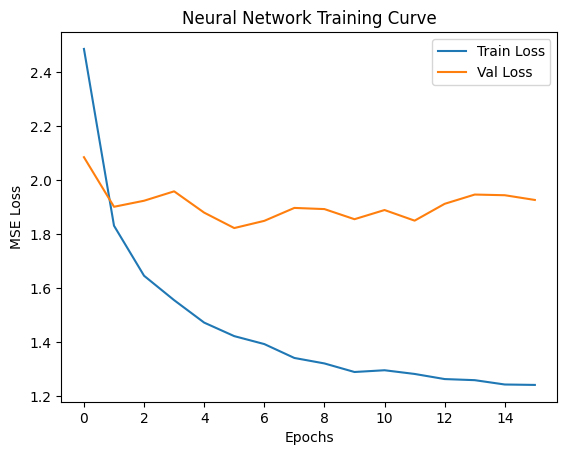

In [6]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Neural Network Training Curve')
plt.legend()
plt.show()

In [7]:
print("R² Score (NN):", r2_score(y_test, y_pred_nn))
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
print("RMSE (NN):", rmse_nn)

R² Score (NN): 0.3452981212295432
RMSE (NN): 1.3964395583615676
